In [1]:
import os
import urllib.request
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

INK = '#2b2b2b'
TEAL = '#2f6b76'
OCHRE = '#c0852f'
BRICK = '#a4503e'
STEM = '#b9b0a2'
PANEL = '#f7f3ec'
GRIDC = '#ded6c8'

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'font.size': 10,
    'font.family': 'serif',
    'figure.facecolor': 'white',
    'axes.facecolor': PANEL,
    'axes.edgecolor': '#9a9486',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titlelocation': 'left',
    'axes.titlepad': 8,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK
})


def grid_h(ax):
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRIDC, lw=0.7)
    ax.grid(axis='x', visible=False)


ruta_archivo = '/content/sample_data/chronic_kidney_disease.arff'

if not os.path.exists(ruta_archivo):
    print(f"Archivo no encontrado en {ruta_archivo}. Descargándolo desde tu repositorio de GitHub...")
    os.makedirs(os.path.dirname(ruta_archivo), exist_ok=True)
    url_directa = 'https://raw.githubusercontent.com/treicimedina/Enfermedad-Renal/main/chronic_kidney_disease.arff'
    try:
        urllib.request.urlretrieve(url_directa, ruta_archivo)
        print("¡Descarga completada con éxito!")
    except Exception as e:
        raise FileNotFoundError(f"No se pudo descargar el archivo de GitHub: {e}")

columnas = []
datos = []
leyendo_datos = False

with open(ruta_archivo, 'r', encoding='utf-8') as f:
    for line in f:
        line_clean = line.strip()
        if not line_clean or line_clean.startswith('%'):
            continue
        if line_clean.lower().startswith('@attribute'):
            parts = line_clean.split()
            col_name = parts[1].strip("'\"")
            columnas.append(col_name)
        elif line_clean.lower().startswith('@data'):
            leyendo_datos = True
            continue
        if leyendo_datos:
            fila = [celda.strip() for celda in line_clean.split(',')]
            if len(fila) == len(columnas):
                datos.append(fila)

df = pd.DataFrame(datos, columns=columnas)

df['class'] = df['class'].astype(str).str.strip()

df['target_numeric'] = df['class'].map({'ckd': 1, 'notckd': 0})

TARGET = 'target_numeric'

C_HEMO = 'hemo'
C_PCV = 'pcv'
C_UREA = 'bu'
C_CREAT = 'sc'
C_HTN = 'htn'

print('Filas y columnas cargadas:', df.shape)
print('Distribución de la variable objetivo (TARGET):')
print(df['class'].value_counts())

Filas y columnas cargadas: (397, 26)
Distribución de la variable objetivo (TARGET):
class
ckd       248
notckd    149
Name: count, dtype: int64


In [2]:
df_prep = df.copy()

variables_numericas = ['age', 'bu', 'sc', 'hemo', 'pcv']
for col in variables_numericas:
    df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

df_prep = df_prep[df_prep['age'] > 0].copy()

for c in ['bu', 'sc']:
    limite_superior = df_prep[c].quantile(0.99)
    df_prep[c] = df_prep[c].clip(upper=limite_superior)

nan_hemo = int(df_prep['hemo'].isna().sum())
nan_pcv = int(df_prep['pcv'].isna().sum())

print(f"Filas tras filtrar edad: {len(df_prep)}")
print(f"Faltantes -> Hemoglobina: {nan_hemo} | Volumen Celular (PCV): {nan_pcv}")

Filas tras filtrar edad: 388
Faltantes -> Hemoglobina: 50 | Volumen Celular (PCV): 67


In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

df_imp = df.copy()
cols_clinicas = ['hemo', 'pcv', 'bu', 'sc', 'age']
for col in cols_clinicas:
    df_imp[col] = pd.to_numeric(df_imp[col], errors='coerce')

pred_hemo = ['bu', 'sc', 'age']
pred_pcv = ['age', 'hemo']

todas_las_variables = list(set(['hemo', 'pcv'] + pred_hemo + pred_pcv))
comp = df_imp.dropna(subset=todas_las_variables).copy()

print('Correlaciones clínicas que justifican los predictores (limpias de NaNs):')
print('  Hemoglobina vs ', {p: round(np.corrcoef(comp['hemo'], comp[p])[0, 1], 3) for p in pred_hemo})
print('  Vol. Celular vs', {p: round(np.corrcoef(comp['pcv'], comp[p])[0, 1], 3) for p in pred_pcv})

lm_hemo = LinearRegression().fit(comp[pred_hemo], comp['hemo'])
lm_pcv = LinearRegression().fit(comp[pred_pcv], comp['pcv'])

pred = lm_hemo.predict(comp[pred_hemo])
resid = comp['hemo'].values - pred

print(f'\nAjuste Hemoglobina: R2={lm_hemo.score(comp[pred_hemo], comp.hemo):.4f} | Vol. Celular (PCV): R2={lm_pcv.score(comp[pred_pcv], comp.pcv):.4f}')
print('\nVerificación de supuestos (regresión de Hemoglobina):')
print(f'  residuos: media={resid.mean():.4f}, sd={resid.std():.4f}, asimetría={stats.skew(resid):.2f}')
print(f'  corr(residuo, ajustado)={np.corrcoef(resid, pred)[0, 1]:.3f} -> linealidad en media OK; residuos NO normales')

variabilidad_reducida = (1 - pred.std() / comp['hemo'].std()) * 100
print(f'  encogimiento: sd(observado)={comp.hemo.std():.2f} vs sd(imputado)={pred.std():.2f} ({variabilidad_reducida:.1f}% menos)')
print(f'  valores faltantes listos para imputar: Hemoglobina={int(df_imp.hemo.isna().sum())}, Vol. Celular (PCV)={int(df_imp.pcv.isna().sum())}')

Correlaciones clínicas que justifican los predictores (limpias de NaNs):
  Hemoglobina vs  {'bu': np.float64(-0.613), 'sc': np.float64(-0.395), 'age': np.float64(-0.224)}
  Vol. Celular vs {'age': np.float64(-0.255), 'hemo': np.float64(0.892)}

Ajuste Hemoglobina: R2=0.3868 | Vol. Celular (PCV): R2=0.7986

Verificación de supuestos (regresión de Hemoglobina):
  residuos: media=-0.0000, sd=2.2428, asimetría=-0.13
  corr(residuo, ajustado)=0.000 -> linealidad en media OK; residuos NO normales
  encogimiento: sd(observado)=2.87 vs sd(imputado)=1.78 (37.9% menos)
  valores faltantes listos para imputar: Hemoglobina=52, Vol. Celular (PCV)=70


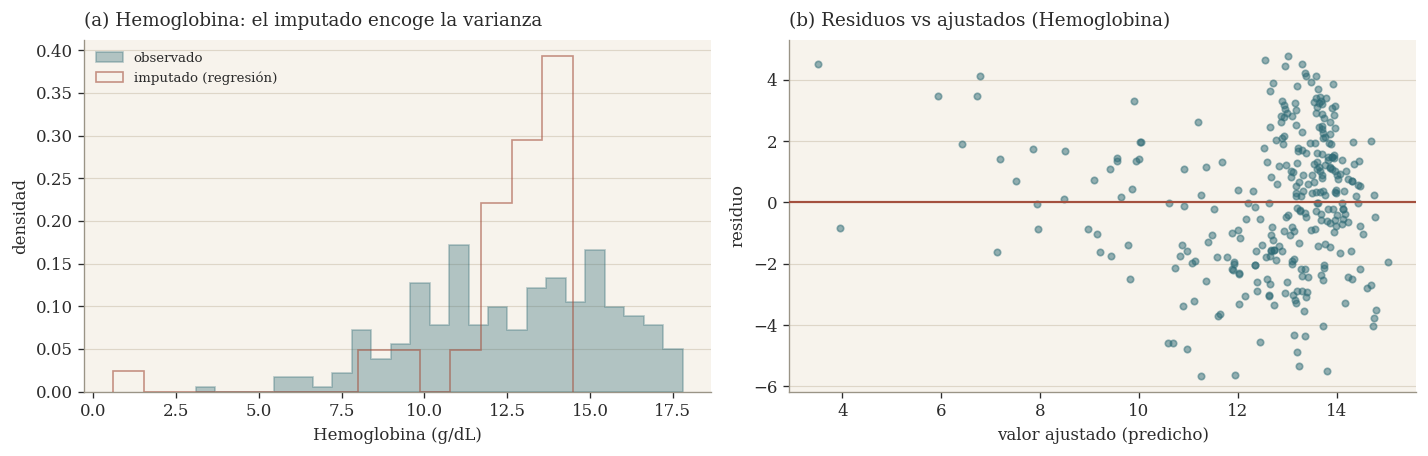

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))

obs = comp['hemo']

df_faltante_hemo = df_imp[df_imp['hemo'].isna() & df_imp[pred_hemo].notna().all(axis=1)]

imp = lm_hemo.predict(df_faltante_hemo[pred_hemo])

ax[0].hist(obs, bins=25, color=TEAL, alpha=0.35, histtype='stepfilled',
           edgecolor=TEAL, lw=1, density=True, label='observado', zorder=2)

ax[0].hist(imp, bins=15, color=BRICK, alpha=0.6, histtype='step',
           lw=1.9, density=True, label='imputado (regresión)', zorder=3)

ax[0].set_title('(a) Hemoglobina: el imputado encoge la varianza')
ax[0].set_xlabel('Hemoglobina (g/dL)')
ax[0].set_ylabel('densidad')
grid_h(ax[0])
ax[0].legend(fontsize=8, frameon=False)

ax[1].scatter(pred, resid, s=15, color=TEAL, alpha=0.5, zorder=2)
ax[1].axhline(0, color=BRICK, lw=1.3, zorder=3)

ax[1].set_title('(b) Residuos vs ajustados (Hemoglobina)')
ax[1].set_xlabel('valor ajustado (predicho)')
ax[1].set_ylabel('residuo')
grid_h(ax[1])

plt.tight_layout()
plt.savefig('fig_imputacion.png', bbox_inches='tight')
plt.show()

In [6]:
import numpy as np
import pandas as pd

df_estudio = df.copy()
cols_estudio = ['hemo', 'bu', 'sc', 'age']
for col in cols_estudio:
    df_estudio[col] = pd.to_numeric(df_estudio[col], errors='coerce')

df_estudio['target_numeric'] = df_estudio['class'].astype(str).str.strip().map({'ckd': 1, 'notckd': 0})
TARGET = 'target_numeric'

df_del = df_estudio.dropna(subset=['hemo']).copy()

df_simple = df_estudio.copy()
mediana_hemo = df_simple['hemo'].median()
df_simple['hemo'] = df_simple['hemo'].fillna(mediana_hemo)

df_reg = df_estudio.copy()
mask_imputables = df_reg['hemo'].isna() & df_reg[pred_hemo].notna().all(axis=1)

predicciones_hemo = lm_hemo.predict(df_reg.loc[mask_imputables, pred_hemo])
df_reg.loc[mask_imputables, 'hemo'] = predicciones_hemo

df_reg['hemo'] = df_reg['hemo'].fillna(mediana_hemo)

tab = []
for nombre, d in [('Eliminación', df_del),
                  ('Imputación simple', df_simple),
                  ('Imputación regresión', df_reg)]:

    d_limpio = d.dropna(subset=[TARGET])

    n_final = len(d_limpio)
    media = d_limpio['hemo'].mean()
    mediana = d_limpio['hemo'].median()
    desviacion = d_limpio['hemo'].std()

    correlacion = np.corrcoef(d_limpio['hemo'], d_limpio[TARGET])[0, 1]

    tab.append([nombre, n_final, media, mediana, desviacion, correlacion])

df_comparativa = pd.DataFrame(
    tab,
    columns=['Estrategia', 'n', 'Media Hemo', 'Mediana Hemo', 'Desv. Estándar', 'Corr con Target']
).set_index('Estrategia')

print(df_comparativa.round(3))

                        n  Media Hemo  Mediana Hemo  Desv. Estándar  \
Estrategia                                                            
Eliminación           345      12.521          12.6           2.918   
Imputación simple     397      12.531          12.6           2.719   
Imputación regresión  397      12.527          12.7           2.827   

                      Corr con Target  
Estrategia                             
Eliminación                    -0.774  
Imputación simple              -0.732  
Imputación regresión           -0.720  


In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = ['hemo', 'pcv', 'bu', 'sc', 'age']

short = {
    'hemo': 'Hemoglobina',
    'pcv': 'Vol_Celular_PCV',
    'bu': 'Urea_Sangre',
    'sc': 'Creatinina_Serica',
    'age': 'Edad'
}

df_ml = df_reg.copy()

for col in FEATURES:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

for col in FEATURES:
    mediana_col = df_ml[col].median()
    df_ml[col] = df_ml[col].fillna(mediana_col)

X = df_ml[FEATURES].values
y = df_ml[TARGET].values

y = y.astype(int)

Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

sc = StandardScaler().fit(Xtr)
Xtr_s = sc.transform(Xtr)
Xte_s = sc.transform(Xte)

print(f'Entrenamiento (train) = {len(ytr):,} pacientes (Enfermedad Renal: {ytr.mean() * 100:.2f}%)')
print(f'Prueba (test)         = {len(yte):,} pacientes (Enfermedad Renal: {yte.mean() * 100:.2f}%)')

Entrenamiento (train) = 277 pacientes (Enfermedad Renal: 62.45%)
Prueba (test)         = 120 pacientes (Enfermedad Renal: 62.50%)


In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

rem = list(range(len(FEATURES)))
sel = []
traj = []

while rem:
    best = None
    for c in rem:

        f = sm.Logit(ytr, sm.add_constant(Xtr_s[:, sel + [c]])).fit(disp=0, maxiter=200)

        if best is None or f.aic < best[0]:
            best = (f.aic, f.bic, c)

    sel.append(best[2])
    rem.remove(best[2])

    traj.append([len(sel), short[FEATURES[best[2]]], best[0], best[1]])

df_trayectoria = pd.DataFrame(traj, columns=['paso', 'variable', 'AIC', 'BIC']).set_index('paso')
print(df_trayectoria.round(1))

print(f'\nPenalización BIC por variable = ln(n) = {np.log(len(ytr)):.1f}')

               variable    AIC    BIC
paso                                 
1           Hemoglobina  131.4  138.6
2       Vol_Celular_PCV  105.7  116.6
3     Creatinina_Serica   91.6  106.1
4           Urea_Sangre   88.4  106.5
5                  Edad   90.1  111.8

Penalización BIC por variable = ln(n) = 5.6


In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

def fit_eval(idx, name):
    m = LogisticRegression(
        penalty=None, max_iter=2000, class_weight='balanced', random_state=SEED
    ).fit(Xtr_s[:, idx], ytr)

    pte = m.predict_proba(Xte_s[:, idx])[:, 1]
    ptr = m.predict_proba(Xtr_s[:, idx])[:, 1]
    yhat = (pte >= 0.5).astype(int)

    return {
        'name': name,
        'idx': idx,
        'model': m,
        'auc_tr': roc_auc_score(ytr, ptr),
        'auc': roc_auc_score(yte, pte),
        'acc': accuracy_score(yte, yhat),
        'prec': precision_score(yte, yhat),
        'rec': recall_score(yte, yhat),
        'f1': f1_score(yte, yhat),
        'pte': pte,
        'yhat': yhat,
        'yhat_tr': (ptr >= 0.5).astype(int),
    }

idx1 = [FEATURES.index(c) for c in ['age', 'bu', 'sc']]

idx2 = list(range(len(FEATURES)))

idx3 = [FEATURES.index(c) for c in ['hemo', 'pcv', 'age']]

M1 = fit_eval(idx1, 'M1 (dominio fisiológico)')
M2 = fit_eval(idx2, 'M2 (completo)')
M3 = fit_eval(idx3, 'M3 (reducido/hematología)')

cvk = StratifiedKFold(5, shuffle=True, random_state=SEED)

for M in [M1, M2, M3]:
    cv = cross_val_score(
        LogisticRegression(
            penalty=None, max_iter=3000, class_weight='balanced', random_state=SEED
        ),
        Xtr_s[:, M['idx']],
        ytr,
        cv=cvk,
        scoring='roc_auc',
    )
    M['cv'] = cv.mean()
    M['cv_sd'] = cv.std()

print('M1 (fisiológico):', [short[FEATURES[i]] for i in idx1])
print('M2 (completo):   ', [short[FEATURES[i]] for i in idx2])
print(
    'M3 (reducido):   ',
    [short[FEATURES[i]] for i in idx3],
    '(descarta marcadores químicos de urea y creatinina)',
)

perf = pd.DataFrame(
    [
        [
            M['name'],
            len(M['idx']),
            M['auc_tr'],
            M['auc'],
            f"{M['cv']:.3f}+/-{M['cv_sd']:.3f}",
            M['acc'],
            M['prec'],
            M['rec'],
            M['f1'],
        ]
        for M in [M1, M2, M3]
    ],
    columns=[
        'Modelo',
        'n_vars',
        'AUC_tr',
        'AUC_test',
        'CV_AUC',
        'Acc',
        'Prec',
        'Recall',
        'F1',
    ],
).set_index('Modelo')

print('\n', perf.to_string())

best = M2
print('\nModelo final de referencia:', best['name'])

M1 (fisiológico): ['Edad', 'Urea_Sangre', 'Creatinina_Serica']
M2 (completo):    ['Hemoglobina', 'Vol_Celular_PCV', 'Urea_Sangre', 'Creatinina_Serica', 'Edad']
M3 (reducido):    ['Hemoglobina', 'Vol_Celular_PCV', 'Edad'] (descarta marcadores químicos de urea y creatinina)

                            n_vars    AUC_tr  AUC_test         CV_AUC       Acc      Prec    Recall        F1
Modelo                                                                                                      
M1 (dominio fisiológico)        3  0.915129  0.942815  0.917+/-0.025  0.891667  1.000000  0.826667  0.905109
M2 (completo)                   5  0.984660  0.991407  0.988+/-0.015  0.958333  0.986111  0.946667  0.965986
M3 (reducido/hematología)       3  0.978101  0.976000  0.980+/-0.022  0.941667  0.959459  0.946667  0.953020

Modelo final de referencia: M2 (completo)


In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

idxb = best['idx']

sm_fit = sm.Logit(ytr, sm.add_constant(Xtr_s[:, idxb])).fit(disp=0, maxiter=300)

names_b = ['const'] + [short[FEATURES[i]] for i in idxb]

B = 500
ntr = len(ytr)
boot = np.zeros((B, len(idxb) + 1))
Xtr_b = Xtr_s[:, idxb]

for b in range(B):

    ii = rng.integers(0, ntr, ntr)

    mb = LogisticRegression(penalty=None, max_iter=1000).fit(Xtr_b[ii], ytr[ii])

    boot[b, 0] = mb.intercept_[0]
    boot[b, 1:] = mb.coef_[0]

ciw = sm_fit.conf_int()

rows = []
for i, nm in enumerate(names_b):
    cl, ch = np.percentile(boot[:, i], [2.5, 97.5])

    orb = np.exp(boot[:, i])
    ol, oh = np.percentile(orb, [2.5, 97.5])

    coef_analitico = sm_fit.params[i]
    or_analitico = np.exp(coef_analitico)

    estable = 'si' if (ol > 1) == (oh > 1) else 'REVISAR'

    rows.append([
        nm, coef_analitico, ciw[i, 0], ciw[i, 1],
        cl, ch, or_analitico, ol, oh, estable
    ])

df_estabilidad = pd.DataFrame(
    rows,
    columns=[
        'Variable', 'coef', 'coefWaldInf', 'coefWaldSup',
        'coefBootInf', 'coefBootSup', 'OR', 'ORbootInf',
        'ORbootSup', 'Estable'
    ]
).set_index('Variable')

print(df_estabilidad.round(3).to_string())

                     coef  coefWaldInf  coefWaldSup  coefBootInf  coefBootSup            OR  ORbootInf     ORbootSup  Estable
Variable                                                                                                                     
const               8.938        4.773       13.102        5.721       17.152  7.612692e+03    305.489  2.824219e+07       si
Hemoglobina        -3.569       -5.213       -1.925       -6.568       -2.442  2.800000e-02      0.001  8.700000e-02       si
Vol_Celular_PCV    -2.366       -3.939       -0.794       -5.843       -1.349  9.400000e-02      0.003  2.590000e-01       si
Urea_Sangre        -2.615       -4.701       -0.529       -5.916       -0.314  7.300000e-02      0.003  7.320000e-01       si
Creatinina_Serica  23.032        9.742       36.322       11.274       46.912  1.006090e+10  78766.985  2.559617e+20       si
Edad                0.175       -0.434        0.784       -0.773        1.034  1.191000e+00      0.462  2.814000e+00  

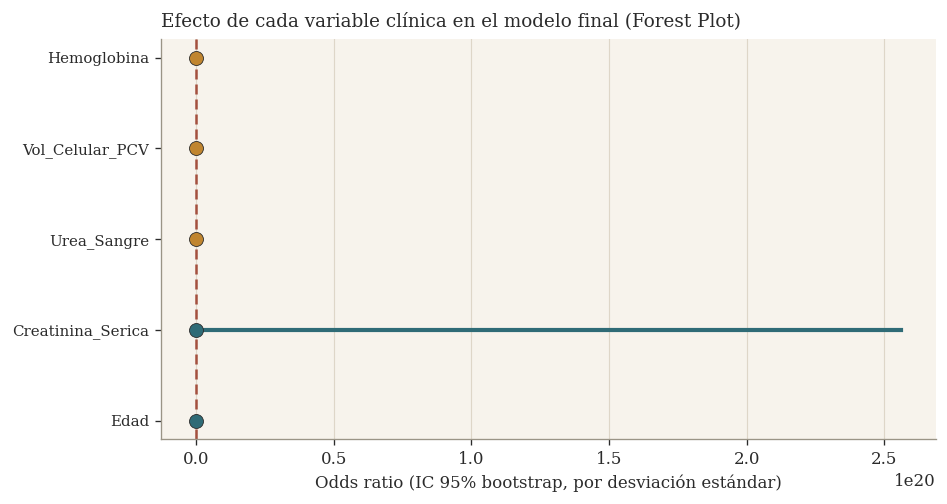

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4.3))

rr = [r for r in rows if r[0] != 'const']
yy = np.arange(len(rr))[::-1]

for r, yv in zip(rr, yy):
    orr, lo, hi = r[6], r[7], r[8]

    col = TEAL if orr > 1 else OCHRE

    ax.plot([lo, hi], [yv, yv], color=col, lw=2.5, zorder=2)

    ax.scatter(orr, yv, color=col, s=70, edgecolor=INK, lw=0.5, zorder=3)

ax.axvline(1, color=BRICK, ls=(0, (4, 2)), lw=1.5, zorder=1)

ax.set_yticks(yy)
ax.set_yticklabels([r[0] for r in rr], fontsize=9)

ax.set_xlabel('Odds ratio (IC 95% bootstrap, por desviación estándar)')
ax.set_title('Efecto de cada variable clínica en el modelo final (Forest Plot)')

ax.set_axisbelow(True)
ax.grid(axis='x', color=GRIDC, lw=0.7)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig('fig_bootstrap_or.png', bbox_inches='tight')
plt.show()

In [15]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xv = Xtr_s[:, idxb]

vif = pd.DataFrame({
    'Variable': [short[FEATURES[i]] for i in idxb],
    'VIF': [variance_inflation_factor(Xv, i) for i in range(len(idxb))]
}).set_index('Variable')

print("Análisis de Multicolinealidad (VIF):")
print(vif.round(2))

base = sm_fit.predict(sm.add_constant(Xv))

pr = (ytr - base) / np.sqrt(base * (1 - base))

residuos_extremos = int(np.sum(np.abs(pr) > 3))
porcentaje_extremos = np.mean(np.abs(pr) > 3) * 100

print(f'\nResiduos de Pearson extremos (|r| > 3): {residuos_extremos:,} de {len(pr):,} ({porcentaje_extremos:.2f}%)')

Análisis de Multicolinealidad (VIF):
                    VIF
Variable               
Hemoglobina        3.89
Vol_Celular_PCV    3.55
Urea_Sangre        1.98
Creatinina_Serica  1.47
Edad               1.07

Residuos de Pearson extremos (|r| > 3): 4 de 277 (1.44%)


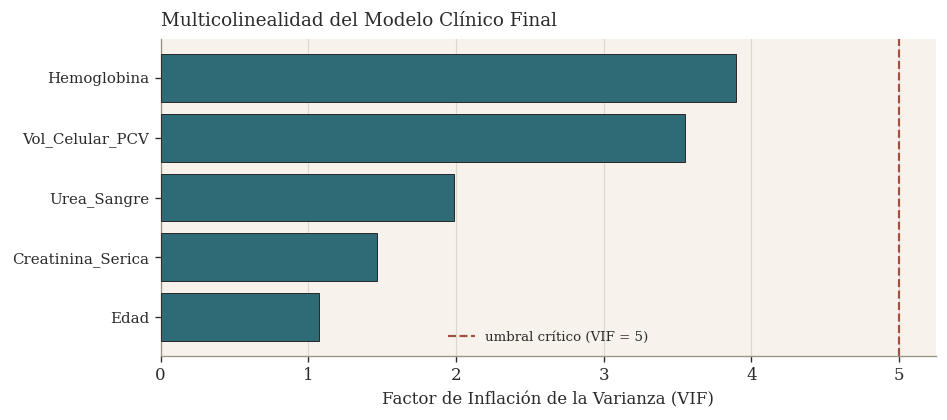

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.6))

vv = vif.sort_values('VIF')

ax.barh(
    range(len(vv)),
    vv['VIF'],
    color=TEAL,
    edgecolor=INK,
    lw=0.6,
    zorder=3
)

ax.axvline(
    5,
    color=BRICK,
    ls='--',
    lw=1.3,
    label='umbral crítico (VIF = 5)',
    zorder=2
)

ax.set_yticks(range(len(vv)))
ax.set_yticklabels(vv.index, fontsize=9)
ax.set_xlabel('Factor de Inflación de la Varianza (VIF)')
ax.set_title('Multicolinealidad del Modelo Clínico Final')

ax.set_axisbelow(True)
ax.grid(axis='x', color=GRIDC, lw=0.7)
ax.grid(axis='y', visible=False)
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('fig_vif.png', bbox_inches='tight')
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

yhat_tr = best['yhat_tr']
yhat_te = best['yhat']

cm_tr = confusion_matrix(ytr, yhat_tr)
cm_te = confusion_matrix(yte, yhat_te)

print('======================================================')
print('  MATRIZ DE CONFUSIÓN - ENTRENAMIENTO')
print('======================================================')
print(cm_tr)
print(f"  Exactitud (Acc) : {accuracy_score(ytr, yhat_tr):.3f}")
print(f"  Sensibilidad (Recall) : {recall_score(ytr, idxh_tr := yhat_tr):.3f}  <- clave para no omitir enfermos")
print(f"  Precisión (Prec)      : {precision_score(ytr, yhat_tr):.3f}")

print('\n======================================================')
print('  MATRIZ DE CONFUSIÓN - PRUEBA (VALIDACIÓN EXTERNA)')
print('======================================================')
print(cm_te)
print(f"  Exactitud (Acc) : {accuracy_score(yte, yhat_te):.3f}")
print(f"  Sensibilidad (Recall) : {recall_score(yte, yhat_te):.3f}  <- capacidad de detección real")
print(f"  Precisión (Prec)      : {precision_score(yte, yhat_te):.3f}")
print('======================================================')

  MATRIZ DE CONFUSIÓN - ENTRENAMIENTO
[[100   4]
 [ 12 161]]
  Exactitud (Acc) : 0.942
  Sensibilidad (Recall) : 0.931  <- clave para no omitir enfermos
  Precisión (Prec)      : 0.976

  MATRIZ DE CONFUSIÓN - PRUEBA (VALIDACIÓN EXTERNA)
[[44  1]
 [ 4 71]]
  Exactitud (Acc) : 0.958
  Sensibilidad (Recall) : 0.947  <- capacidad de detección real
  Precisión (Prec)      : 0.986


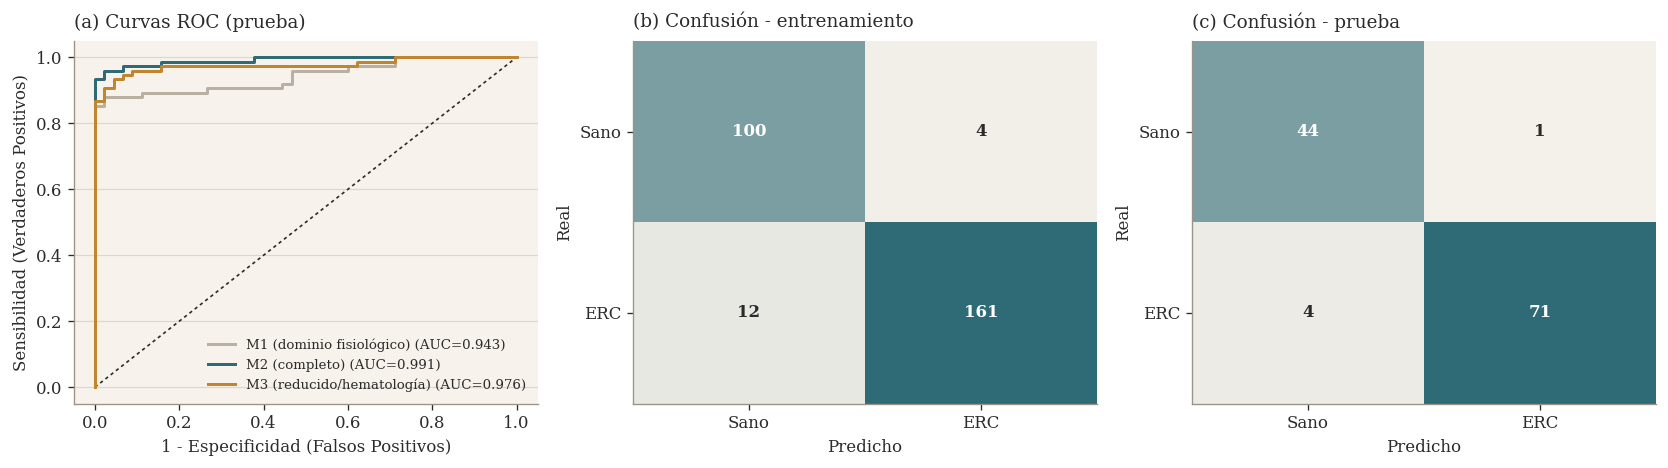

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_curve

cm_editorial = LinearSegmentedColormap.from_list('cm_editorial', [PANEL, TEAL])

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for M, c in [(M1, STEM), (M2, TEAL), (M3, OCHRE)]:
    fpr, tpr, _ = roc_curve(yte, M['pte'])
    ax[0].plot(
        fpr,
        tpr,
        color=c,
        lw=1.8,
        label=f"{M['name']} (AUC={M['auc']:.3f})",
        zorder=3
    )

ax[0].plot([0, 1], [0, 1], color=INK, ls=(0, (2, 2)), lw=1, zorder=2)
ax[0].set_title('(a) Curvas ROC (prueba)')
ax[0].set_xlabel('1 - Especificidad (Falsos Positivos)')
ax[0].set_ylabel('Sensibilidad (Verdaderos Positivos)')
grid_h(ax[0])
ax[0].legend(fontsize=8, frameon=False, loc='lower right')

matrices_confusion = [
    (ax[1], cm_tr, '(b) Confusión - entrenamiento'),
    (ax[2], cm_te, '(c) Confusión - prueba')
]

for a, cm, tt in matrices_confusion:
    vmax = cm.max()
    a.imshow(cm, cmap=cm_editorial, aspect='auto', vmin=0, vmax=vmax)

    for (i, j), v in np.ndenumerate(cm):
        txt_color = 'white' if v / vmax > 0.55 else INK
        a.text(
            j, i, f'{v:,}',
            ha='center', va='center',
            color=txt_color, fontsize=10, fontweight='bold'
        )

    a.set_xticks([0, 1])
    a.set_xticklabels(['Sano', 'ERC'])
    a.set_yticks([0, 1])
    a.set_yticklabels(['Sano', 'ERC'])

    a.set_xlabel('Predicho')
    a.set_ylabel('Real')
    a.set_title(tt)
    a.grid(False)

plt.tight_layout()
plt.savefig('fig_desempeno.png', bbox_inches='tight')
plt.show()

In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

keyv = ['hemo', 'sc', 'age']
keyn = ['Hemoglobina', 'Creatinina', 'Edad']

rows = []

for nm, d in [
    ('Eliminación', df_del),
    ('Imputación simple', df_simple),
    ('Imputación regresión', df_reg),
]:

    d_clean = d.copy()

    for col in FEATURES:
        d_clean[col] = pd.to_numeric(d_clean[col], errors='coerce')

    for col in FEATURES:
        mediana_col = d_clean[col].median()
        d_clean[col] = d_clean[col].fillna(mediana_col)

    d_clean[TARGET] = pd.to_numeric(d_clean[TARGET], errors='coerce')
    d_clean = d_clean.dropna(subset=[TARGET])

    Xa = d_clean[FEATURES].values
    ya = d_clean[TARGET].values.astype(int)

    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
        Xa, ya, test_size=0.30, random_state=SEED, stratify=ya
    )

    sca = StandardScaler().fit(Xa_tr)
    Xtr_scaled = sca.transform(Xa_tr)
    Xte_scaled = sca.transform(Xa_te)

    smf = sm.Logit(ya_tr, sm.add_constant(Xtr_scaled)).fit(
        disp=0, maxiter=300
    )
    ci = smf.conf_int()

    clf = LogisticRegression(
        penalty=None, max_iter=2000, class_weight='balanced', random_state=SEED
    ).fit(Xtr_scaled, ya_tr)
    probs_test = clf.predict_proba(Xte_scaled)[:, 1]
    au = roc_auc_score(ya_te, probs_test)

    r = [nm, len(ya_te), round(au, 3)]

    for kv in keyv:

        j = FEATURES.index(kv) + 1
        r.append(f'{smf.params[j]:+.3f} [{ci[j, 0]:+.3f}, {ci[j, 1]:+.3f}]')

    rows.append(r)

df_comparativa_final = pd.DataFrame(
    rows,
    columns=['Estrategia', 'n_test', 'AUC'] + [f'coef {n}' for n in keyn],
).set_index('Estrategia')

print(df_comparativa_final.to_string())

                      n_test    AUC         coef Hemoglobina             coef Creatinina                coef Edad
Estrategia                                                                                                       
Eliminación              104  0.992  -3.496 [-5.450, -1.542]  +28.687 [+11.559, +45.815]  -0.174 [-0.968, +0.621]
Imputación simple        120  0.993  -3.160 [-4.578, -1.742]  +23.257 [+10.062, +36.451]  +0.150 [-0.432, +0.731]
Imputación regresión     120  0.991  -3.569 [-5.213, -1.925]   +23.032 [+9.742, +36.322]  +0.175 [-0.434, +0.784]


In [22]:
import os

figuras_guardadas = sorted(
    f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')
)

print('Visualizaciones de diagnóstico clínico generadas con éxito:')
print('===============================================================')
for fig in figuras_guardadas:
    print(f' ➜  [Archivo]: {fig}')
print('===============================================================')
print(f'Total de figuras listas para reporte: {len(figuras_guardadas)}')

Visualizaciones de diagnóstico clínico generadas con éxito:
 ➜  [Archivo]: fig_bootstrap_or.png
 ➜  [Archivo]: fig_desempeno.png
 ➜  [Archivo]: fig_imputacion.png
 ➜  [Archivo]: fig_vif.png
Total de figuras listas para reporte: 4
